# ECQL: LoRA против базовой модели

Перевод вопроса на русском в запрос на внутреннем языке ECQL.

Ноутбук работает в двух местах:
- **Google Colab, T4** - база грузится в 4 битах через bitsandbytes;
- **Mac, Apple Silicon** - bitsandbytes не работает, база грузится в bf16.

Порядок: 
- самопроверка метрик, 
- два прогона базовой модели, 
- обучение адаптера,
- прогон с адаптером, 
- сравнение.

## 1. Окружение

In [44]:
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !pip install -q \
        transformers==5.15.1 \
        peft==0.20.0 \
        trl==1.10.0 \
        accelerate==1.14.0 \
        datasets==5.0.1 \
        nltk==3.10.3 \
        matplotlib==3.11.1 \
        bitsandbytes

from importlib.metadata import PackageNotFoundError, version

for package in ("torch", "transformers", "peft", "trl", "accelerate", "datasets", "nltk", "matplotlib", "bitsandbytes"):
    try:
        print(f"{package:16} {version(package)}")
    except PackageNotFoundError:
        print(f"{package:16} не установлен")

torch            2.13.0
transformers     5.15.1
peft             0.20.0
trl              1.10.0
accelerate       1.14.0
datasets         5.0.1
nltk             3.10.3
matplotlib       3.11.1
bitsandbytes     не установлен


## 2. Код и данные

Код лежит в репозитории: `src/ecql_dataset`. 

В Colab репозиторий клонируется, локально берётся из каталога, где лежит ноутбук.

In [45]:
from pathlib import Path

REPO_URL = "https://github.com/samtakoy/llm-engineer-ecql-and-metrcis.git"

if IN_COLAB:
    ROOT = Path("/content") / Path(REPO_URL).stem
    if not ROOT.exists():
        !git clone -q {REPO_URL} {ROOT}
else:
    ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()

sys.path.insert(0, str(ROOT / "src"))

DATASET = ROOT / "dataset" / "ecql"
OUTPUT = ROOT / "output"

print("корень:", ROOT)
print("датасет:", DATASET)

корень: /Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics
датасет: /Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/dataset/ecql


In [46]:
import json

def read_jsonl(path):
    return [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line]

train = read_jsonl(DATASET / "train.jsonl")
val = read_jsonl(DATASET / "val.jsonl")
test = read_jsonl(DATASET / "test.jsonl")


print(f"train {len(train)}, val {len(val)}, test {len(test)}, "
      f"из них challenge {sum(r['meta']['challenge'] for r in test)}")

print()
print(test[0]["input"])
print(test[0]["output"])

train 176, val 32, test 68, из них challenge 15

Отзывы из Пятигорска и Лермонтова
FETCH [REVIEWS] WHERE @city IS 'Пятигорск' || @city IS 'Лермонтов'


## 3. Устройство

Отсюда берутся размер батча и способ загрузки модели.

In [47]:
import torch

if torch.cuda.is_available():
    DEVICE = "cuda"
    DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    LOAD_IN_4BIT = True
    BATCH_SIZE = 4
elif torch.backends.mps.is_available():
    DEVICE = "mps"
    DTYPE = torch.bfloat16
    LOAD_IN_4BIT = False
    # Память у Apple Silicon общая с системной, её десятки гигабайт: батч
    # ограничен скоростью, а не объёмом.
    BATCH_SIZE = 4
else:
    DEVICE = "cpu"
    DTYPE = torch.float32
    LOAD_IN_4BIT = False
    BATCH_SIZE = 1

print({"устройство": DEVICE, "тип": str(DTYPE), "4 бита": LOAD_IN_4BIT, "батч": BATCH_SIZE})

{'устройство': 'mps', 'тип': 'torch.bfloat16', '4 бита': False, 'батч': 4}


## 4. Самопроверка метрик

Метрике подаются эталоны вместо ответов модели. Идеальный прогон обязан дать единицу по синтаксису, логике и строке и ноль галлюцинаций.

Проверка идёт до запуска модели: сломанная метрика делает бессмысленными все последующие цифры.

In [48]:
from ecql_dataset.notebook.eval.product import judge, self_check

print(self_check(records=test))

{'синтаксис': 1.0, 'логика': 1.0, 'сущность': 1.0, 'поля': 1.0, 'операторы': 1.0, 'значения': 1.0, 'суффикс': 1.0, 'галлюцинации': 0.0, 'строка': 1.0, 'ответов': 68}


- ответов 68 — весь тест;
- синтаксис 1.0 — все 68 разобрались по грамматике;
- логика 1.0 и пять частей по 1.0 — каждый совпал с собой;
- строка 1.0 — посимвольно тоже;
- галлюцинации 0.0 — чужого языка и выдуманных полей нет.

### Проверка на испорченных ответах

Самопроверка показала, что метрика не занижает. Теперь посмотрим — что не завышает.

Шесть ответов, каждый сломан по-своему. Логика должна упасть везде, кроме перестановки условий: там порядок другой, а смысл тот же.

In [49]:
reference = "FETCH [PLACES] WHERE @category IS 'food' && @price_rub BELOW 700 AS LIST"
cases = {
    "переставлены условия": "FETCH [PLACES] WHERE @price_rub BELOW 700 && @category IS 'food' AS LIST",
    "испорчено значение": "FETCH [PLACES] WHERE @category IS 'culture' && @price_rub BELOW 700 AS LIST",
    "перепутан оператор": "FETCH [PLACES] WHERE @category IS 'food' && @price_rub ABOVE 700 AS LIST",
    "забыт суффикс": "FETCH [PLACES] WHERE @category IS 'food' && @price_rub BELOW 700",
    "SQL вместо ECQL": "SELECT * FROM places WHERE category = 'food'",
    "выдуманное поле": "FETCH [PLACES] WHERE @cuisine IS 'food' && @price_rub BELOW 700 AS LIST",
}

for name, prediction in cases.items():
    verdict = judge(prediction=prediction, reference=reference)
    print(f"{name:22} строка={int(verdict.exact)} логика={int(verdict.logic)} "
          f"галлюцинации={int(verdict.hallucination)}  {verdict.reason}")

переставлены условия   строка=0 логика=1 галлюцинации=0  
испорчено значение     строка=0 логика=0 галлюцинации=0  не совпало: значения
перепутан оператор     строка=0 логика=0 галлюцинации=0  не совпало: операторы
забыт суффикс          строка=0 логика=0 галлюцинации=0  не совпало: суффикс
SQL вместо ECQL        строка=0 логика=0 галлюцинации=1  чужой язык запросов: запрос не разбирается по грамматике: "SELECT * FROM places WHERE category = 'food'"
выдуманное поле        строка=0 логика=0 галлюцинации=1  поля нет у [PLACES]: @cuisine


**Проверка: Текстовая метрика не заменяет логическую**

В каждом эталоне портится одно значение. Запрос остаётся правильным по
синтаксису и почти совпадает с эталоном как текст, но возвращает не те данные.

In [50]:
import re

from ecql_dataset.notebook.eval import text as text_metrics
from ecql_dataset.notebook.eval.product import evaluate

references = [record["output"] for record in test]
broken = [re.sub(r"'[^']*'", "'сломано'", reference, count=1) for reference in references]

rows = {}
for name, predictions in (("эталоны", references), ("одно значение испорчено", broken)):
    product, _ = evaluate(records=test, predictions=predictions)
    rows[name] = text_metrics.score(predictions=predictions, references=references) | {
        "логика": product["логика"],
        "синтаксис": product["синтаксис"],
    }

names = ["exact", "token_f1", "bleu", "meteor", "rouge_l", "cider", "синтаксис", "логика"]
print(f"{'метрика':12} {'эталоны':>10} {'испорчено':>12}")
for name in names:
    print(f"{name:12} {rows['эталоны'][name]:>10.3f} {rows['одно значение испорчено'][name]:>12.3f}")

метрика         эталоны    испорчено
exact             1.000        0.000
token_f1          1.000        0.943
bleu              1.000        0.850
meteor            1.000        0.940
rouge_l           1.000        0.943
cider             1.000        0.617
синтаксис         1.000        1.000
логика            1.000        0.000


Испорченный запрос синтаксически правильный и текстово почти совпадает с эталоном, но возвращает другие данные.

Все текстовые метрики, кроме exact, показывают 0.6–0.94 — «почти правильно». Логика показывает 0.

exact строгая, но слепая к перестановке условий.

Значит ориентироваться на них нельзя — подмену значения они не видят. 

Текстовые метрики отвечают «стало ли похоже на язык», логическая — «правильный ли запрос».

## 5. Промпты

Два промпта. 

Короткий — роль и схема данных, тот же текст лежит в поле `instruction` датасета. 

Полный — он же плюс правила языка словами - для базовой модели без дообучения.

Оба собираются из словаря и схемы модулем `ecql_dataset.prompt`, руками не пишутся: пополнится датасет — поменяются сами.

**Посмотрим на полный промпт:**

In [51]:
import json

from ecql_dataset.prompt import build_instruction

vocabulary = json.loads((DATASET / "source" / "vocabulary.json").read_text(encoding="utf-8"))

SHORT_PROMPT = build_instruction(vocabulary=vocabulary, with_rules=False)
FULL_PROMPT = build_instruction(vocabulary=vocabulary, with_rules=True)

assert SHORT_PROMPT == train[0]["instruction"], "короткий промпт разошёлся с датасетом"
assert FULL_PROMPT.startswith(SHORT_PROMPT), "полный промпт обязан начинаться коротким"

print(f"короткий {len(SHORT_PROMPT)} знаков, полный {len(FULL_PROMPT)}")
print()
print("Полный промпт для базовой модели:\n---")
print(FULL_PROMPT)


короткий 2018 знаков, полный 3989

Полный промпт для базовой модели:
---
Ты переводишь вопрос человека в запрос на ECQL - внутреннем языке запросов компании.
Отвечай одной строкой запроса, без пояснений.

Схема данных:

[PLACES]
- @name, строка, примеры: Фитнесс центр, Дача "Золотой курган" Л.К.Менякова, Кофейня Dr.Coff, Интурист и т.д.
- @city, строка, примеры: Москва, Волгоград, Пятигорск и т.д.; объект вне населённого пункта - 'вне городов'
- @category, строка, допустимые значения: culture, food, shopping, lodging, nature, service, water, activity, transport
- @price_rub, число, примеры: 300, 400, 500, 1300 и т.д.
- @price_kind, строка, допустимые значения: average_check, per_night
- @object_kind, строка, допустимые значения: monument, ensemble, heritage_site
- @heritage_status, строка, допустимые значения: regional, federal, local
- @wheelchair, строка, допустимые значения: yes, no, limited

[REVIEWS]
- @name, строка, примеры: Интурист, Пространство лофт, Кристелла, Олимпия и т.д.


### Обучающий пример целиком

In [52]:
from ecql_dataset.prompt import build_training_messages

example = train[0]
messages = build_training_messages(
    instruction=SHORT_PROMPT,
    question=example["input"],
    answer=example["output"],
)

for message in messages:
    print(f"--- {message['role']} ---")
    print(message["content"])

--- system ---
Ты переводишь вопрос человека в запрос на ECQL - внутреннем языке запросов компании.
Отвечай одной строкой запроса, без пояснений.

Схема данных:

[PLACES]
- @name, строка, примеры: Фитнесс центр, Дача "Золотой курган" Л.К.Менякова, Кофейня Dr.Coff, Интурист и т.д.
- @city, строка, примеры: Москва, Волгоград, Пятигорск и т.д.; объект вне населённого пункта - 'вне городов'
- @category, строка, допустимые значения: culture, food, shopping, lodging, nature, service, water, activity, transport
- @price_rub, число, примеры: 300, 400, 500, 1300 и т.д.
- @price_kind, строка, допустимые значения: average_check, per_night
- @object_kind, строка, допустимые значения: monument, ensemble, heritage_site
- @heritage_status, строка, допустимые значения: regional, federal, local
- @wheelchair, строка, допустимые значения: yes, no, limited

[REVIEWS]
- @name, строка, примеры: Интурист, Пространство лофт, Кристелла, Олимпия и т.д.
- @city, строка, примеры: Москва, Волгоград, Пятигорск и т

## 6. Модель

Отладка идёт на Qwen3-0.6B.

In [53]:
# TODO: сюда переедет load_model из ecql_dataset.notebook.generate
# Переедет: загрузка токенизатора (padding_side="left", pad_token из eos),
# ветка 4 бит через BitsAndBytesConfig для Colab, загрузка модели и model.eval().

from ecql_dataset.notebook.generate import load_model

MODEL_NAME = "Qwen/Qwen3-0.6B"

model, tokenizer = load_model(model_name=MODEL_NAME, dtype=DTYPE, load_in_4bit=LOAD_IN_4BIT)

parameters = sum(p.numel() for p in model.parameters())
print(f"{MODEL_NAME}: параметров {parameters / 1e9:.2f} млрд, устройство {model.device}")

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 6868.81it/s]


Qwen/Qwen3-0.6B: параметров 0.60 млрд, устройство cpu


### Что уходит в модель

In [54]:
from ecql_dataset.notebook.generate import render_prompt

print(render_prompt(tokenizer=tokenizer, instruction="Инструкция сюда", question=test[0]["input"]))

<|im_start|>system
Инструкция сюда<|im_end|>
<|im_start|>user
Отзывы из Пятигорска и Лермонтова<|im_end|>
<|im_start|>assistant
<think>

</think>




пустой `<think></think>` — работа enable_thinking=False. 

Шаблон Qwen3 сам вставляет закрытый блок рассуждений: модель видит, что рассуждать уже «закончено», и сразу пишет ответ.

### Генерация

Из ответа берётся строка запроса — `extract_query` отбрасывает обрамление кода, размышления и пояснения вокруг.

Проверка на трёх вопросах на коротком промпте, в котором нет правил языка.

In [55]:
from ecql_dataset.notebook.generate import generate

probe = test[:3]
answers = generate(
    model=model,
    tokenizer=tokenizer,
    questions=[record["input"] for record in probe],
    instruction=SHORT_PROMPT,
    batch_size=BATCH_SIZE,
)

for record, answer in zip(probe, answers):
    print(record["input"])
    print("эталон:", record["output"])
    print("ответ: ", answer)
    print()

генерация: 100%|██████████| 1/1 [00:11<00:00, 11.33s/батч]

Отзывы из Пятигорска и Лермонтова
эталон: FETCH [REVIEWS] WHERE @city IS 'Пятигорск' || @city IS 'Лермонтов'
ответ:  @city Пятигорск, @name Лермонтова.

Трамвай за двадцать-сорок рублей
эталон: FETCH [FARES] WHERE @transport IS 'tram' && @price_rub ABOVE 20 && @price_rub BELOW 40
ответ:  @transport, @route_start, @route_end, @fare_class, @price_rub

«Оазис» — что там с чистотой?
эталон: FETCH [REVIEWS] WHERE @name IS 'Оазис' && @aspects CONTAINS 'чистота'
ответ:  SELECT @heritage_status AS "чистота" WHERE @object_class = 'monument';



**Результат:**

ожидаемо плохой, модель не знает правил языка - ей их не показали.

### Дадим модели полный промпт:

In [56]:
answers_full = generate(
    model=model,
    tokenizer=tokenizer,
    questions=[record["input"] for record in probe],
    instruction=FULL_PROMPT,
    batch_size=BATCH_SIZE,
)

for record, short_answer, full_answer in zip(probe, answers, answers_full):
    print(record["input"])
    print("эталон:  ", record["output"])
    print("короткий:", short_answer)
    print("полный:  ", full_answer)
    print()


генерация: 100%|██████████| 1/1 [00:26<00:00, 26.92s/батч]

Отзывы из Пятигорска и Лермонтова
эталон:   FETCH [REVIEWS] WHERE @city IS 'Пятигорск' || @city IS 'Лермонтов'
короткий: @city Пятигорск, @name Лермонтова.
полный:   FETCH [REVIEWS] WHERE @city IS 'Пятигорск' || @city IS 'Лермонтова' AS LIST

Трамвай за двадцать-сорок рублей
эталон:   FETCH [FARES] WHERE @transport IS 'tram' && @price_rub ABOVE 20 && @price_rub BELOW 40
короткий: @transport, @route_start, @route_end, @fare_class, @price_rub
полный:   FETCH [FARES] WHERE @transport IS 'tram' && @price_rub IS 2000 AS JSON

«Оазис» — что там с чистотой?
эталон:   FETCH [REVIEWS] WHERE @name IS 'Оазис' && @aspects CONTAINS 'чистота'
короткий: SELECT @heritage_status AS "чистота" WHERE @object_class = 'monument';
полный:   FETCH [PLACES] WHERE @city IS 'Оазис' && @object_kind IS 'monument' && @heritage_status IS 'regional' AS LIST



**Результат:**

Более похоже на правду, но все равно ни одного правльного ответа и куча галлюцинаций.

## 7. Прогон 1: база, короткий промпт

Первый прогон — контроль для адаптера: тот обучается на коротком промпте, значит и сравнивать его надо с базой на том же промпте. 

Сделаем по правилам, хотя и и так понятно - будут 0 метрики.

Результаты складываются в `runs` — из него потом собирается сводная таблица и разбор расхождений.

In [57]:
from ecql_dataset.notebook.eval.product import evaluate

RUNS_DIR = OUTPUT / "runs" / MODEL_NAME.split("/")[-1].lower()
RUNS_DIR.mkdir(parents=True, exist_ok=True)

runs = {}

def run(*, title, name, model, instruction, records=test):
    """Прогоняет модель по тесту, считает метрики и сохраняет результат.

    Аргументы:
        title: имя прогона в сводной таблице.
        name: имя файла результата в output/runs.
        model: модель, отвечающая на вопросы.
        instruction: инструкция, общая для всех вопросов прогона.
        records: записи теста.

    Возвращает:
        Метрики прогона.
    """
    predictions = generate(
        model=model,
        tokenizer=tokenizer,
        questions=[record["input"] for record in records],
        instruction=instruction,
        batch_size=BATCH_SIZE,
    )
    metrics, verdicts = evaluate(records=records, predictions=predictions)
    runs[title] = {"predictions": predictions, "metrics": metrics, "verdicts": verdicts}

    (RUNS_DIR / f"{name}.json").write_text(
        json.dumps(
            {
                "title": title,
                "model": MODEL_NAME,
                "instruction": instruction,
                "metrics": metrics,
                "answers": [
                    {"input": record["input"], "output": record["output"], "prediction": prediction}
                    for record, prediction in zip(records, predictions)
                ],
            },
            ensure_ascii=False,
            indent=1,
        ),
        encoding="utf-8",
    )
    return metrics

In [15]:
metrics = run(title="база, короткий промпт", name="base-short", model=model, instruction=SHORT_PROMPT)

for name, value in metrics.items():
    print(f"{name:14} {value}")

NameError: name 'run' is not defined

**Результат:**

Ожидаемо все плохо (можно было и не греть GPU)

Первые ответы прогона рядом с эталонами:

In [16]:
for record, prediction in list(zip(test, runs["база, короткий промпт"]["predictions"]))[:5]:
    print(record["input"])
    print("эталон:", record["output"])
    print("ответ: ", prediction)
    print()

Отзывы из Пятигорска и Лермонтова
эталон: FETCH [REVIEWS] WHERE @city IS 'Пятигорск' || @city IS 'Лермонтов'
ответ:  @city Пятигорск, @name Лермонтова.

Трамвай за двадцать-сорок рублей
эталон: FETCH [FARES] WHERE @transport IS 'tram' && @price_rub ABOVE 20 && @price_rub BELOW 40
ответ:  @transport, @route_start, @route_end, @fare_class, @price_rub

«Оазис» — что там с чистотой?
эталон: FETCH [REVIEWS] WHERE @name IS 'Оазис' && @aspects CONTAINS 'чистота'
ответ:  SELECT @heritage_status AS "чистота" WHERE @object_class = 'monument';

Отзывы о хостелах на три
эталон: FETCH [REVIEWS] WHERE @object_class IS 'hostel' && @rating IS 3
ответ:  @object_kind = hostel;

Средний чек в Кисловодске выше двухсот
эталон: FETCH [PLACES] WHERE @price_kind IS 'average_check' && @price_rub ABOVE 200 && @city IS 'Кисловодск'
ответ:  price_rub > 200



## 8. Прогон 2: база, полный промпт

Та же модель и тот же тест, меняется одна инструкция: к роли и схеме добавлены правила языка.

Прогон отвечает на вопрос «зачем адаптер, если грамматику можно описать словами». 

In [17]:
metrics_full = run(title="база, полный промпт", name="base-full", model=model, instruction=FULL_PROMPT)

for name, value in metrics_full.items():
    print(f"{name:14} {value}")

генерация: 100%|██████████| 68/68 [08:34<00:00,  7.57s/батч]

синтаксис      0.9411764705882353
логика         0.07352941176470588
сущность       0.5735294117647058
поля           0.17647058823529413
операторы      0.16176470588235295
значения       0.11764705882352941
суффикс        0.2647058823529412
галлюцинации   0.14705882352941177
строка         0.07352941176470588
ответов        68


Ответы двух прогонов рядом: видно, что дали правила.

In [20]:
# short_run = runs["база, короткий промпт"]["predictions"]
full_run = runs["база, полный промпт"]["predictions"]

# for record, short_answer, full_answer in list(zip(test, short_run, full_run))[:5]:
for record, full_answer in list(zip(test, full_run))[:5]:
    print(record["input"])
    print("эталон:  ", record["output"])
    # print("короткий:", short_answer)
    print("полный:  ", full_answer)
    print()

Отзывы из Пятигорска и Лермонтова
эталон:   FETCH [REVIEWS] WHERE @city IS 'Пятигорск' || @city IS 'Лермонтов'
полный:   FETCH [REVIEWS] WHERE @city IS 'Пятигорск' || @city IS 'Лермонтова' AS LIST

Трамвай за двадцать-сорок рублей
эталон:   FETCH [FARES] WHERE @transport IS 'tram' && @price_rub ABOVE 20 && @price_rub BELOW 40
полный:   FETCH [FARES] WHERE @transport IS 'tram' && @price_rub IS 2000 AS JSON

«Оазис» — что там с чистотой?
эталон:   FETCH [REVIEWS] WHERE @name IS 'Оазис' && @aspects CONTAINS 'чистота'
полный:   FETCH [PLACES] WHERE @city IS 'Оазис' && @object_kind IS 'monument' && @heritage_status IS 'regional' AS LIST

Отзывы о хостелах на три
эталон:   FETCH [REVIEWS] WHERE @object_class IS 'hostel' && @rating IS 3
полный:   FETCH [REVIEWS] WHERE @object_class IS 'hostel' AS LIST

Средний чек в Кисловодске выше двухсот
эталон:   FETCH [PLACES] WHERE @price_kind IS 'average_check' && @price_rub ABOVE 200 && @city IS 'Кисловодск'
полный:   FETCH [PLACES] WHERE @price_rub I

## 9. Обучение адаптера

Дообучается не вся модель, а низкоранговые добавки к матрицам внимания — LoRA. Базовые веса заморожены, обучаемых параметров меньше процента.

| Параметр | Значение | Почему |
|---|---|---|
| `r` | 8 | рекомендация задания; язык небольшой — четыре сущности, шесть операторов, ранг 8 их вмещает. На шаге 14 сравним с 16 |
| `lora_alpha` | 16 | вдвое больше ранга, обычная пропорция: масштаб добавки `alpha / r` равен 2 |
| `lora_dropout` | 0.05 | датасет маленький, 176 пар; лёгкий dropout сдерживает заучивание |
| `target_modules` | q_proj, k_proj, v_proj, o_proj | проекции внимания, как указано в задании |
| `learning_rate` | 2e-4 | рекомендация задания |
| эпохи | 3 | 176 пар — за одну эпоху модель форму языка не усвоит |

Потери считаются только по ответу ассистента: инструкция и вопрос в них не входят. Иначе модель тренировалась бы переписывать схему, а не отвечать.

In [35]:
ADAPTER_NAME = "qwen3-0.6b-r8"

ADAPTER_DIR = OUTPUT / "adapters" / ADAPTER_NAME
TRAINING_DIR = OUTPUT / "training" / ADAPTER_NAME

for directory in (ADAPTER_DIR, TRAINING_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# True — учить заново; False — взять готовые веса и сразу идти к прогону 3.
TRAIN_ADAPTER = True

# Ссылка на веса для TRAIN_ADAPTER=False. Заполняется после выгрузки на Google Drive.
ADAPTER_URL = ""

print("веса адаптера:", ADAPTER_DIR)
print("ход обучения:", TRAINING_DIR)

веса адаптера: /Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/output/adapters/qwen3-0.6b-r8
ход обучения: /Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/output/training/qwen3-0.6b-r8
результаты прогонов: /Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/output/runs/qwen3-0.6b


### Google Drive

Среда Colab исчезает вместе со всем, что в ней записано. Веса адаптера переживают перезапуск только на диске.

Монтирование запрашивает доступ к аккаунту — Colab покажет диалог, его надо подтвердить вручную. Локально ветка пропускается.

In [36]:
DRIVE_DIR = None

if IN_COLAB and TRAIN_ADAPTER:
    from google.colab import drive

    drive.mount("/content/drive")
    DRIVE_DIR = Path("/content/drive/MyDrive/ecql") / ADAPTER_NAME
    DRIVE_DIR.mkdir(parents=True, exist_ok=True)
    print("веса будут скопированы в", DRIVE_DIR)

### Обучающие примеры

Пара датасета превращается в три сообщения — те же, что на инференсе: инструкция системой, вопрос пользователем, эталон ответом ассистента.

Инструкция короткая, без правил языка: адаптер должен выучить грамматику весами, а не читать её из промпта.

In [37]:
from datasets import Dataset

from ecql_dataset.prompt import build_training_messages

def to_messages(record):
    """Превращает пару датасета в сообщения обучающего примера.

    Аргументы:
        record: строка датасета.

    Возвращает:
        Словарь с ключом messages.
    """
    return {
        "messages": build_training_messages(
            instruction=SHORT_PROMPT,
            question=record["input"],
            answer=record["output"],
        )
    }

train_dataset = Dataset.from_list([to_messages(record) for record in train])
val_dataset = Dataset.from_list([to_messages(record) for record in val])

print(f"обучающих примеров {len(train_dataset)}, проверочных {len(val_dataset)}")
print(train_dataset[0]["messages"][1])
print(train_dataset[0]["messages"][2])

обучающих примеров 176, проверочных 32
{'role': 'user', 'content': 'Что пишут про парковку в отзывах на четвёрку? Завтрак не интересует'}
{'role': 'assistant', 'content': "FETCH [REVIEWS] WHERE @aspects CONTAINS 'парковка' && @rating IS 4 && @aspects NOT CONTAINS 'завтрак'"}


### Настройка обучения

`assistant_only_loss=True` считает потери только по ответу ассистента — шаблон Qwen3 размечает его границу сам.

Эффективный батч держим равным восьми: на T4 это четыре примера с накоплением по два шага, на Mac один с накоплением по восемь. Число шагов обучения от устройства не зависит.

In [38]:
from peft import LoraConfig
from trl import SFTConfig, SFTTrainer

LORA_RANK = 8
EFFECTIVE_BATCH = 8

# Потолок эпох. Обучение остановится не здесь, а на лучшей по валидации: она
# сохраняется каждую эпоху и подставляется обратно в конце.
EPOCHS = 5

lora_config = LoraConfig(
    task_type="CAUSAL_LM",
    r=LORA_RANK,
    lora_alpha=2 * LORA_RANK,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    bias="none",
)

training_config = SFTConfig(
    output_dir=str(TRAINING_DIR / "checkpoints"),
    num_train_epochs=EPOCHS,
    learning_rate=2e-4,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=EFFECTIVE_BATCH // BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    eval_strategy="epoch",
    logging_steps=5,
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    max_length=1024,
    assistant_only_loss=True,
    report_to=[],
    seed=17,
)

print(f"эффективный батч {BATCH_SIZE} × {training_config.gradient_accumulation_steps}")

эффективный батч 4 × 2


### Обучение

In [39]:
if TRAIN_ADAPTER:
    trainer = SFTTrainer(
        model=model,
        args=training_config,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        peft_config=lora_config,
        processing_class=tokenizer,
    )
    trainer.model.print_trainable_parameters()
    trainer.train()
    adapter_model = trainer.model
    adapter_model.eval()

Truncating train dataset: 100%|██████████| 176/176 [00:00<00:00, 13231.95 examples/s]
Dropping fully masked examples from train dataset: 100%|██████████| 176/176 [00:00<00:00, 26151.25 examples/s]
Dropping fully masked examples from eval dataset: 100%|██████████| 32/32 [00:00<00:00, 17231.70 examples/s]
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


trainable params: 2,293,760 || all params: 598,343,680 || trainable%: 0.3834


/Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.813154,0.586896,0.774560,144837.000000,0.822417
2,0.396892,0.350461,0.387909,289674.000000,0.884715
3,0.278753,0.279742,0.282542,434511.000000,0.909044
4,0.213544,0.257586,0.242888,579348.000000,0.913468
5,0.100601,0.257652,0.224684,724185.000000,0.921682


/Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/.venv/lib/python3.13/site-packages/torch/utils/data/da

In [41]:
# Сколько памяти понадобилось при этих параметрах. Пик на MPS не считается,
# берётся память после обучения: кеш аллокатора к этому моменту уже вырос
# до рабочего максимума.
if DEVICE == "mps":
    print(f"память: {torch.mps.driver_allocated_memory() / 1e9:.1f} ГБ"
          f" из {torch.mps.recommended_max_memory() / 1e9:.1f} ГБ")
elif DEVICE == "cuda":
    print(f"память: пик {torch.cuda.max_memory_allocated() / 1e9:.1f} ГБ")


память: 7.8 ГБ из 38.7 ГБ


### График loss

Цель — устойчивое снижение ошибки. Разъезд кривых train и validation означает заучивание: обучающие пары модель запомнила, новых не понимает.

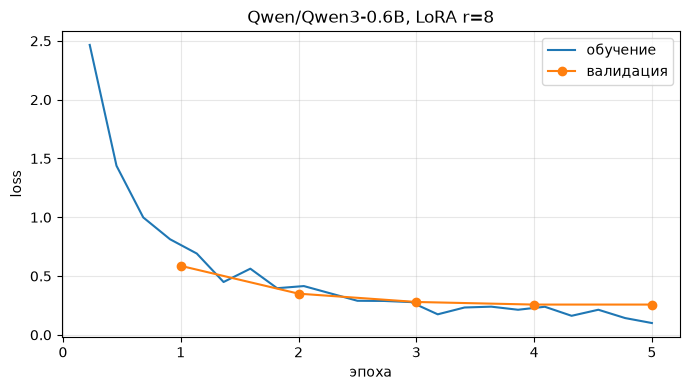

последний train loss: 0.1006008505821228
последний val loss:   0.2576521635055542


In [42]:
import matplotlib.pyplot as plt

if TRAIN_ADAPTER:
    history = trainer.state.log_history
    (TRAINING_DIR / "history.json").write_text(
        json.dumps(history, ensure_ascii=False, indent=1), encoding="utf-8"
    )

    train_points = [(row["epoch"], row["loss"]) for row in history if "loss" in row]
    val_points = [(row["epoch"], row["eval_loss"]) for row in history if "eval_loss" in row]

    figure, axes = plt.subplots(figsize=(7, 4))
    axes.plot(*zip(*train_points), label="обучение")
    axes.plot(*zip(*val_points), marker="o", label="валидация")
    axes.set_xlabel("эпоха")
    axes.set_ylabel("loss")
    axes.set_title(f"{MODEL_NAME}, LoRA r={LORA_RANK}")
    axes.legend()
    axes.grid(alpha=0.3)
    figure.tight_layout()
    figure.savefig(TRAINING_DIR / "loss.png", dpi=150)
    plt.show()

    print("последний train loss:", train_points[-1][1])
    print("последний val loss:  ", val_points[-1][1])

### Веса адаптера

При обучении веса сохраняются в `output/adapters` и копируются на Google Drive. При `TRAIN_ADAPTER=False` они скачиваются оттуда же и подключаются к базовой модели.

In [43]:
from peft import PeftModel

if TRAIN_ADAPTER:
    adapter_model.save_pretrained(str(ADAPTER_DIR))
    print("сохранено:", ADAPTER_DIR)

    if DRIVE_DIR is not None:
        import shutil

        shutil.copytree(ADAPTER_DIR, DRIVE_DIR, dirs_exist_ok=True)
        print("скопировано на диск:", DRIVE_DIR)
else:
    if not (ADAPTER_DIR / "adapter_config.json").exists():
        if not ADAPTER_URL:
            raise ValueError("нет весов адаптера: заполните ADAPTER_URL или включите TRAIN_ADAPTER")
        !pip install -q gdown
        !gdown --folder -q "{ADAPTER_URL}" -O "{ADAPTER_DIR}"

    adapter_model = PeftModel.from_pretrained(model, str(ADAPTER_DIR))
    adapter_model.eval()
    print("веса подключены:", ADAPTER_DIR)

сохранено: /Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/output/adapters/qwen3-0.6b-r8


## 10. Прогон 3: адаптер

Тот же тест, та же генерация, тот же короткий промпт, что и в первом прогоне. Отличие одно — адаптер поверх базовых весов.

Сравнение с первым прогоном показывает, что дало обучение. Сравнение со вторым — что сильнее: правила в промпте или грамматика в весах.

In [58]:
metrics_lora = run(
    title=f"адаптер r={LORA_RANK}",
    name=f"lora-r{LORA_RANK}",
    model=adapter_model,
    instruction=SHORT_PROMPT,
)

for name, value in metrics_lora.items():
    print(f"{name:14} {value}")

генерация: 100%|██████████| 17/17 [00:34<00:00,  2.05s/батч]

синтаксис      0.7941176470588235
логика         0.19117647058823528
сущность       0.5882352941176471
поля           0.3235294117647059
операторы      0.27941176470588236
значения       0.20588235294117646
суффикс        0.6764705882352942
галлюцинации   0.08823529411764706
строка         0.17647058823529413
ответов        68


Ответы адаптера рядом с эталонами.

In [59]:
lora_answers = runs[f"адаптер r={LORA_RANK}"]["predictions"]

for record, prediction in list(zip(test, lora_answers))[:8]:
    mark = "совпал" if prediction == record["output"] else "разошёлся"
    print(record["input"])
    print("эталон:", record["output"])
    print("ответ: ", prediction, f"({mark})")
    print()

Отзывы из Пятигорска и Лермонтова
эталон: FETCH [REVIEWS] WHERE @city IS 'Пятигорск' || @city IS 'Лермонтов'
ответ:  FETCH [REVIEWS] WHERE @city IS 'Пятигорск' || @city IS 'Лермонтов' (совпал)

Трамвай за двадцать-сорок рублей
эталон: FETCH [FARES] WHERE @transport IS 'tram' && @price_rub ABOVE 20 && @price_rub BELOW 40
ответ:  FETCH [FARES] WHERE @transport IS 'tram' && @price_rub IS 200 (разошёлся)

«Оазис» — что там с чистотой?
эталон: FETCH [REVIEWS] WHERE @name IS 'Оазис' && @aspects CONTAINS 'чистота'
ответ:  FETCH [REVIEWS] WHERE @name IS 'Оазис' && @aspects CONTAINS 'чистота' (совпал)

Отзывы о хостелах на три
эталон: FETCH [REVIEWS] WHERE @object_class IS 'hostel' && @rating IS 3
ответ:  FETCH [REVIEWS] WHERE @object_class IS 'hostel' && @rating IS 3 (совпал)

Средний чек в Кисловодске выше двухсот
эталон: FETCH [PLACES] WHERE @price_kind IS 'average_check' && @price_rub ABOVE 200 && @city IS 'Кисловодск'
ответ:  FETCH [PLACES] WHERE @price_rub IS 200 && @city IS 'Кисловодск' 